[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com)

Author: **Dongyuan Gao**

Course: HSLU Computer Vision — Lecture 3 Project

Based on the style of the lecturer's notebooks by *Safouane El Ghazouali* (TOELT LLC / HSLU).

# -----  -----  -----  -----  -----  -----  -----  -----

# 🚗 Fine-Tuning YOLOv10 for Self-Driving Object Detection

In this notebook we fine-tune a pre-trained **YOLOv10n** on the **Udacity Self-Driving Car dataset** (≈15,000 dashcam images, 11 classes: car, truck, pedestrian, biker, traffic light, traffic sign, …).

The goal: build a **real-time detector** that finds vehicles, pedestrians and traffic signals in dashcam footage — the core perception step of any self-driving stack.

### Why YOLO?
- **Real-time**: a single forward pass gives all boxes + labels.
- **Detection, not classification**: tells us *what* AND *where*.
- **Easy fine-tuning** via the Ultralytics library.

### What to Learn
- Downloading a pre-labelled detection dataset from Roboflow.
- Fine-tuning YOLOv10n on custom classes.
- Reading training curves and validation metrics (mAP).
- Running inference on images and videos.
- Plugging the fine-tuned weights into a **live webcam** demo on your Mac.

# 🧰 Environment Setup

Install Ultralytics (the YOLO library) and Roboflow (for dataset download).
Colab already ships with PyTorch + OpenCV, so we only need these two.

In [1]:
!pip install -q ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.9/175.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.9 MB/s eta 0:00:00


### Import Libraries & Check GPU

We need a GPU for reasonable training speed — Colab gives us a free T4.
If this prints `cuda` you're good. If it prints `cpu`, switch runtime to GPU:
**Runtime → Change runtime type → T4 GPU**.

In [2]:
from ultralytics import YOLO
from roboflow import Roboflow
import torch
import os, glob, yaml
import cv2
import matplotlib.pyplot as plt
from PIL import Image
%matplotlib inline

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
print(f'PyTorch version: {torch.__version__}')

# Explanation
# - device: tells YOLO where to run (GPU is ~30x faster than CPU).
# - Ultralytics auto-uses this device unless we override it.

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cpu
PyTorch version: 2.10.0+cpu


# 📂 Downloading the Dataset from Roboflow

We'll use Roboflow's **Udacity Self-Driving Car** dataset (≈15k images, 11 classes, already split train/valid/test with YOLO-format labels).

**Steps:**
1. Go to https://public.roboflow.com/object-detection/self-driving-car
2. Click **Download Dataset** → pick **YOLOv8** format (compatible with v10).
3. Roboflow shows you a **personalised snippet** with your API key — paste it in the next cell, replacing the placeholder.

The download goes **directly to Colab's disk** (not your laptop) — very fast.

In [3]:
### ----  PASTE THE SNIPPET ROBOFLOW GIVES YOU HERE  ---- ###
### It will look something like the block below. Replace the placeholder api_key.

rf = Roboflow(api_key="")
project = rf.workspace("roboflow-gw7yv").project("self-driving-car")
dataset = project.version(3).download("yolov8")

### ---------------------------------------------------- ###

print(f'Dataset downloaded to: {dataset.location}')

# Explanation
# - dataset.location: absolute path to the downloaded folder
# - Inside you'll find: data.yaml, train/, valid/, test/
# - data.yaml lists class names and folder paths YOLO needs
# - YOLOv8 format works for v10 as well (same label structure).

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Self-Driving-Car-3 in yolov8:: 100%|██████████| 59606/59606 [00:17<00:00, 3411.40it/s]


Dataset downloaded to: /content/Self-Driving-Car-3


### Inspect the Dataset

Before training, always look at a few images to confirm labels make sense.
YOLO labels are **normalised** (values between 0 and 1) in the format:

```
class  x_center  y_center  width  height
```

We convert them back to pixel coordinates to draw the boxes.

Classes (11): ['biker', 'car', 'pedestrian', 'trafficLight', 'trafficLight-Green', 'trafficLight-GreenLeft', 'trafficLight-Red', 'trafficLight-RedLeft', 'trafficLight-Yellow', 'trafficLight-YellowLeft', 'truck']


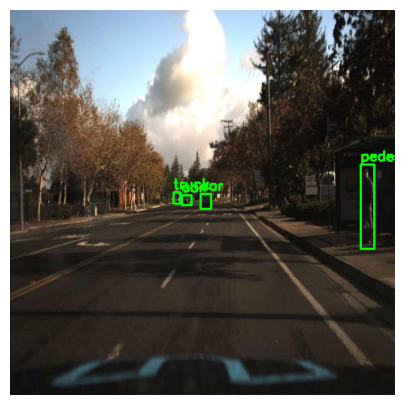

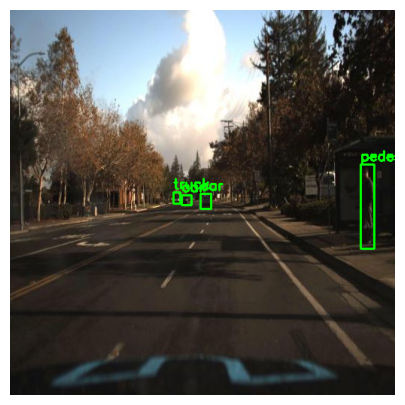

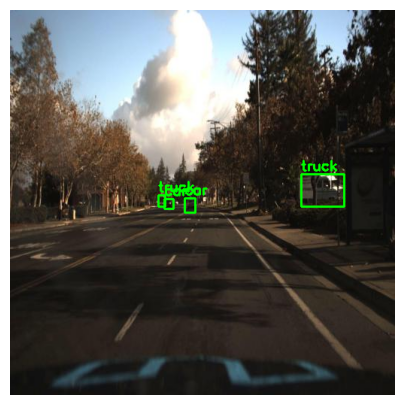

In [6]:
images_dir = f"{dataset.location}/export/images"
labels_dir = f"{dataset.location}/export/labels"

# Read class names from data.yaml
with open(f"{dataset.location}/data.yaml") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg['names']
print(f'Classes ({len(class_names)}):', class_names)

def plot_image_with_boxes(image_path, label_path):
    img = cv2.imread(image_path)
    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                cls, x, y, bw, bh = map(float, line.strip().split())
                cls = int(cls)
                # YOLO normalised → pixel coords
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(img, class_names[cls], (x1, max(y1 - 5, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    plt.figure(figsize=(8, 5))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# Show 3 sample images
sample_files = sorted(os.listdir(images_dir))[:3]
for file in sample_files:
    img_path = os.path.join(images_dir, file)
    lbl_path = os.path.join(labels_dir, file.rsplit('.', 1)[0] + '.txt')
    plot_image_with_boxes(img_path, lbl_path)

In [5]:
import os

def list_files(startpath):
    for root, dirs, files in os.walk(startpath):
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * (level)
        print(f'{indent}{os.path.basename(root)}/')
        subindent = ' ' * 4 * (level + 1)
        for f in files[:3]: # show only first 3 files
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}...')

# Check the structure of the downloaded dataset
print(f"Checking structure of: {dataset.location}")
list_files(dataset.location)

Checking structure of: /content/Self-Driving-Car-3
Self-Driving-Car-3/
    data.yaml
    README.dataset.txt
    README.roboflow.txt
    export/
        images/
            1478732153496111819_jpg.rf.c9cf74c8fd1b59bef7a181c3cdea5e3e.jpg
            1478896594160679973_jpg.rf.anU5qWWZ85hdcj7HwwWo.jpg
            1478020364195691554_jpg.rf.0806e65d666e3c4e764ab0ea9f5318cb.jpg
            ...
        labels/
            1478896040581425375_jpg.rf.9UH0DHXOumC8LYFezypI.txt
            1478020380702593247_jpg.rf.d92d9d8ae8c7aa1ff7f2f5f0bb903f62.txt
            1478896619299788031_jpg.rf.698ead953c3c66ecd8c7d697ec0e84b9.txt
            ...


In [8]:
import yaml

# Path to the data.yaml file
yaml_path = os.path.join(dataset.location, 'data.yaml')

# Load the current configuration
with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Update the paths to point to the 'export' folder using absolute paths
# This fixes the issue where YOLO can't find the 'train' folder
config['train'] = os.path.join(dataset.location, 'export', 'images')
config['val'] = os.path.join(dataset.location, 'export', 'images')
config['test'] = os.path.join(dataset.location, 'export', 'images')

# Write the updated config back to data.yaml
with open(yaml_path, 'w') as f:
    yaml.dump(config, f)

print(f"Updated {yaml_path} with new paths:")
print(f"Train: {config['train']}")
print(f"Val:   {config['val']}")

Updated /content/Self-Driving-Car-3/data.yaml with new paths:
Train: /content/Self-Driving-Car-3/export/images
Val:   /content/Self-Driving-Car-3/export/images


# 📦 Loading a Pre-trained YOLOv10n Model

We start from **`yolov10n.pt`** (nano = smallest, fastest) pretrained on **COCO** (80 everyday classes).

Fine-tuning means: **reuse COCO's learned features**, then adjust the output head for our 11 self-driving classes. That is why we don't need millions of images — the model already knows what a "car" looks like from COCO.

Model size options:
- `yolov10n.pt` → Nano (≈3M params) — fastest, fine for demos ✅
- `yolov10s.pt` → Small (≈7M params) — better accuracy
- `yolov10m.pt` → Medium (≈15M params) — slower but strongest for a class project

In [ ]:
model = YOLO('yolov10n.pt')
print('YOLOv10n loaded with COCO pretrained weights!')

# 🏋️ Fine-Tuning the Model

Key training arguments:

| Arg | Meaning | Our value |
|---|---|---|
| `data` | Path to data.yaml | from Roboflow |
| `epochs` | Number of passes over the dataset | 30 |
| `imgsz` | Input image size (square) | 512 |
| `batch` | Images per training step | 16 |
| `patience` | Early stop if no improvement for N epochs | 10 |
| `device` | `cuda` = GPU, `cpu` = CPU | auto |

⏱️ **Expected time on Colab T4 GPU: ~45–75 min.**
Ultralytics prints a progress bar per epoch so you can see the ETA.

Results are auto-saved to `runs/detect/selfdriving_v1/` including:
- `weights/best.pt` → best-performing weights
- `results.png` → loss + mAP curves
- `confusion_matrix.png`

In [ ]:
from ultralytics import YOLO

# Initialize the model with pretrained weights to ensure 'model' is defined
model = YOLO('yolov10n.pt')

# Start training using the updated data.yaml with absolute paths
results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=30,
    imgsz=512,
    batch=16,
    patience=10,
    name='selfdriving_v1',
    device=device
)

save_dir = str(model.trainer.save_dir)
print(f'\nRun directory: {save_dir}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Self-Driving-Car-3/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=selfdriving_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

### Look at the Training Curves

`results.png` shows loss (should decrease) and mAP (should increase) over epochs.
If mAP flatlined early, more epochs won't help much.

In [ ]:
results_png = os.path.join(save_dir, 'results.png')
if os.path.exists(results_png):
    plt.figure(figsize=(14, 8))
    plt.imshow(Image.open(results_png))
    plt.axis('off')
    plt.show()
else:
    print('results.png not found — training may still be in progress.')

# 📊 Part 1 — Formal Evaluation (the numbers for report)

**Evaluation** = running the model on a held-out split and computing objective metrics.
We use `model.val()` on the **validation** split (Ultralytics uses the `val:` path from `data.yaml`).

**Key metrics:**
- **Precision** — of the boxes we predicted, how many were correct?
- **Recall** — of all real objects, how many did we find?
- **mAP@0.5** — mean Average Precision at IoU threshold 0.5 (main benchmark number).
- **mAP@0.5:0.95** — stricter; averaged across IoU thresholds 0.5 → 0.95.

A solid YOLOv10n on this dataset typically reaches **mAP@0.5 ≈ 0.55–0.70**.

In [ ]:
val_results = model.val()

print(f'\nPrecision     : {val_results.box.mp:.3f}')
print(f'Recall        : {val_results.box.mr:.3f}')
print(f'mAP@0.5       : {val_results.box.map50:.3f}')
print(f'mAP@0.5:0.95  : {val_results.box.map:.3f}')

# Confusion matrix (which classes get confused with which?)
cm_path = os.path.join(save_dir, 'confusion_matrix.png')
if os.path.exists(cm_path):
    plt.figure(figsize=(10, 10))
    plt.imshow(Image.open(cm_path))
    plt.axis('off')
    plt.title('Confusion Matrix')
    plt.show()

# Explanation
# - val_results.box.* holds aggregated metrics over ALL classes.
# - For per-class metrics, check val_results.box.maps (one value per class).

# 🔍 Part 2 — Qualitative Demo on a Single Test Image

Numbers are nice, but it helps to **see** the model work. We pick a random image from the test split and plot the predicted boxes.

`conf=0.4` filters out low-confidence boxes to keep the output clean.

In [ ]:
test_dir = f'{dataset.location}/test/images'
test_img = os.path.join(test_dir, sorted(os.listdir(test_dir))[0])

results_test = model(test_img, conf=0.4)

annotated = results_test[0].plot()
plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title('Fine-tuned YOLOv10 — Dashcam Detections')
plt.axis('off')
plt.show()

### Exploring the `results` Object

Ultralytics wraps predictions in a `Results` object. The most useful attributes:

| Attribute | What it contains |
|---|---|
| `.boxes.xyxy` | Box corners in pixels `[x1, y1, x2, y2]` |
| `.boxes.conf` | Confidence score (0–1) per box |
| `.boxes.cls` | Class index per box |
| `.names` | Dict mapping class index → class name |

In [ ]:
result = results_test[0]

boxes = result.boxes.xyxy.cpu().numpy()
confs = result.boxes.conf.cpu().numpy()
clses = result.boxes.cls.cpu().numpy().astype(int)
names = result.names

print(f'Found {len(boxes)} objects:\n')
for box, conf, cls in zip(boxes, confs, clses):
    print(f'  {names[cls]:15s}  conf={conf:.2f}  box={box.astype(int).tolist()}')

# 🎥 Part 3 — Video Demo (Upload a Dashcam Clip)

Upload any short dashcam clip (30–60 sec is plenty for a class demo).
Free sources: **Pexels**, **Pixabay**, or a YouTube CC clip downloaded with `yt-dlp`.

The code below processes every frame and **saves an annotated output video** you can download.

In [ ]:
from google.colab import files

# 1. Upload a video from your laptop
uploaded = files.upload()            # pick a dashcam .mp4
video_path = list(uploaded.keys())[0]

# 2. Run detection on every frame — saves to runs/detect/predict*/
model(video_path, save=True, conf=0.4, device=device)

# 3. Find the annotated output and download it
out_candidates = sorted(
    glob.glob('runs/detect/predict*/*.avi') +
    glob.glob('runs/detect/predict*/*.mp4'),
    key=os.path.getmtime
)
if out_candidates:
    out_video = out_candidates[-1]
    print(f'Output file: {out_video}')
    files.download(out_video)
else:
    print('No output video found — check runs/detect/ manually.')

# Explanation
# - Ultralytics writes .avi by default; recent versions may use .mp4.
# - files.download() pops a browser download dialog.

# 💾 Save the Fine-Tuned Weights to Google Drive

Colab sessions are temporary — when the runtime dies, `/content/` is wiped.
Copy `best.pt` to Google Drive so you keep the fine-tuned model.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

best_pt = os.path.join(save_dir, 'weights', 'best.pt')
target_dir = '/content/drive/MyDrive/yolo_selfdriving'
os.makedirs(target_dir, exist_ok=True)

!cp "{best_pt}" "{target_dir}/best.pt"
!cp "{save_dir}/results.png" "{target_dir}/results.png"
print('Saved best.pt and results.png to:', target_dir)

# Also allow direct download to your laptop
files.download(best_pt)

# 📷 Part 4 — Live Webcam Demo on Your Mac

Colab can't access your webcam, but you already have a local script `YOLO_Live.py` that runs YOLOv10 on a live camera feed. After downloading `best.pt` from the cell above, you can point that script at your fine-tuned weights.

### Steps

1. Download `best.pt` to your Mac (the cell above does this automatically).
2. Place it next to `YOLO_Live.py`, e.g. in `Lecture 3/best.pt`.
3. Open `YOLO_Live.py` and change **one line**:

```python
# Before (uses the generic COCO-pretrained model):
model = YOLO('yolov10n.pt')

# After (uses YOUR fine-tuned self-driving model):
model = YOLO('best.pt')
```

4. Make sure you have `ultralytics` installed locally:

```bash
pip install ultralytics opencv-python
```

5. Run the script:

```bash
python3 YOLO_Live.py
```

6. Press **q** to quit the webcam window.

### What to Expect

Your webcam now detects the **11 self-driving classes** you fine-tuned on (car, truck, pedestrian, …). If you point it at a phone/monitor playing a dashcam clip, or print out a street photo, the model should draw coloured boxes in real time at roughly **20–40 FPS** on an M-series Mac.

# 🧠 Interpreting Results — What to Report

When presenting this project, cover:

1. **Dataset**: what it contains, how many images, how many classes.
2. **Model choice**: why YOLOv10n (speed vs accuracy trade-off).
3. **Training curves**: show `results.png` — did loss decrease? did mAP plateau?
4. **Metrics**: precision, recall, mAP@0.5. Note which classes were weakest (check confusion matrix).
5. **Qualitative results**: the annotated dashcam video and/or live webcam demo — the "wow" moment.
6. **Limitations**: small objects (far-away cars), night scenes, weather, class imbalance.
7. **Next steps**: more epochs, bigger model (`yolov10s`), stronger augmentation, add tracking.

# 💡 Student Tasks

1. **Train longer** — bump `epochs` to 50 with `patience=15`. Does mAP improve?
2. **Bigger model** — try `yolov10s.pt` or `yolo11n.pt` and compare training time vs mAP gain.
3. **Different dataset** — try **Tsinghua-Tencent TT100K** (traffic signs only) and compare.
4. **Add tracking** — replace `model(video_path, save=True)` with `model.track(video_path, tracker="bytetrack.yaml", save=True)` so each vehicle keeps a persistent ID across frames.
5. **Measure FPS** — time the video inference and compute frames/second. Is it real-time (>30 FPS)?
6. **Per-class analysis** — print `val_results.box.maps` and discuss which classes are hardest.